# When does conditioning build the class?

The paper shows *that* class-conditional adaptation works. This notebook asks
*when*, during the denoising process, the conditioning actually acts.

Three measurements of the same process, which turn out to disagree:

1. the **instantaneous strength** of the class signal, `‖ε(c) − ε(∅)‖`;
2. how much the **pixels** change when conditioning is restricted to a window of steps;
3. whether the **class survives**, judged by a classifier trained on real data only.

Everything runs on stored artefacts: no GPU, no generation.

In [1]:
%matplotlib inline

import os
import sys

# The project's code uses paths relative to the repository root, so move there.
# The check makes the cell idempotent: re-running it will not climb further up.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt

from XAI import common, plotting

DATASET, EXP = "cifar10", "xAI"
labels = common.get_labels(DATASET)
print(f"{len(labels)} classes: {', '.join(labels)}")

2026-08-31 10:03:25.082026: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-31 10:03:25.136775: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-31 10:03:25.138239: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-31 10:03:28.589509: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck


## 1. The instantaneous strength of the signal

`ε(c) − ε(∅)` is the class signal by definition: the only quantity through which
the class reaches the generation, and exactly what classifier-free guidance
multiplies by UGS. Measuring it requires no attention weights and carries none of
their caveats.

It is reported against `‖ε(∅)‖`, because the scale of the noise prediction changes
along the denoising and absolute norms are not comparable across steps. That
denominator also serves as a sanity check: it should start near 32 = √1024, since
the model is expected to predict standard Gaussian noise over the 16×16×4
dimensions of the latent.

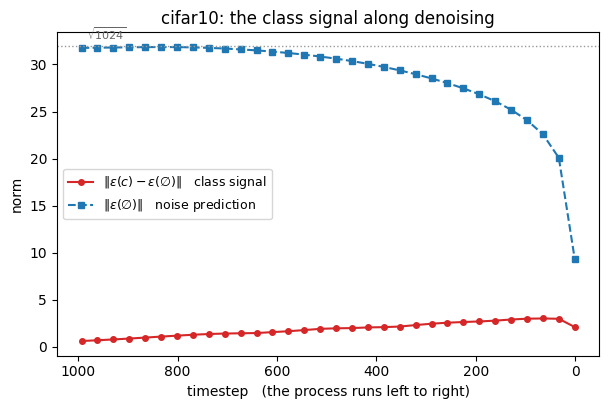

In [3]:
guidance = np.load(f"XAI_Results/Exp_{EXP}/{DATASET}/guidance/steps31_ugs1.752.npz")
timesteps = guidance["timesteps"]

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(timesteps, guidance["absolute"].mean(axis=1), marker="o", ms=4,
        color="#d62728",
        label=r"$\|\epsilon(c) - \epsilon(\emptyset)\|$   class signal")
ax.plot(timesteps, guidance["eps"].mean(axis=1), marker="s", ms=4, ls="--",
        color="#1f77b4",
        label=r"$\|\epsilon(\emptyset)\|$   noise prediction")

reference = np.sqrt(16 * 16 * 4)
ax.axhline(reference, color="0.6", ls=":", lw=1)
ax.annotate(r"$\sqrt{1024}$", (timesteps[0], reference), fontsize=8, color="0.4",
            xytext=(4, 4), textcoords="offset points")

# Denoising runs from the noisiest timestep down to the cleanest, so the axis is
# reversed: left to right is then the direction the process actually takes.
ax.invert_xaxis()
ax.set_xlabel("timestep   (the process runs left to right)")
ax.set_ylabel("norm")
ax.set_title(f"{DATASET}: the class signal along denoising")
ax.legend(fontsize=9)

The signal is **weak while the image is still noise** and grows almost fivefold
along the process. The obvious reading — that conditioning matters most at the end —
turns out to be wrong.

`‖Δε‖` measures the **instantaneous** effect at a given step, not the effect on the
final image. A tiny nudge at the first step is propagated and amplified through the
thirty steps that follow; a large one at the last step has nothing left to act on.
Telling the two apart requires an intervention, not an observation.

## 2. and 3. Pixels against class

The same classes are generated from the same initial noise several times, with
conditioning active only inside a window of steps. Each run is then scored two ways:

- **pixels** — how far the image moved towards the fully-conditioned one, as a
  fraction of the distance between the two extremes (always conditioned, never
  conditioned);
- **class** — whether a ResNet20 trained on real CIFAR-10 only still assigns the
  requested label. The judge never saw a generated image, so its verdict is
  independent of the generator.

     steps     pixels      class
       0-4      26.2%       5.6
       5-9      22.2%      14.0
     10-14      17.9%      20.8
     15-19      13.3%      16.2
     20-24       9.5%      12.2
     25-29       7.3%       8.0
     30-31       3.6%       1.6


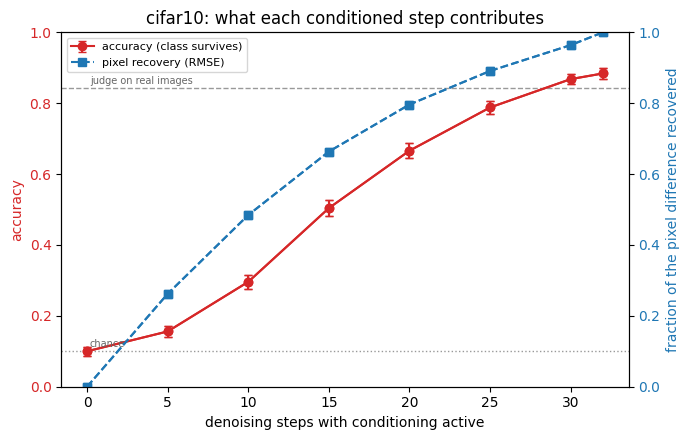

In [4]:
scores = np.load(f"XAI_Results/Exp_{EXP}/{DATASET}/windows/"
                 f"accuracy_steps31_window5.npz")

_ = plotting.conditioning_curves(
    scores["counts"], scores["accuracy"], scores["error"], scores["recovered"],
    chance=1 / len(labels), ceiling=float(scores["real_accuracy"]),
    title=f"{DATASET}: what each conditioned step contributes")

# What each additional block of steps buys, in each of the two currencies.
print(f"{'steps':>10} {'pixels':>10} {'class':>10}")
for i in range(len(scores["counts"]) - 1):
    block = f"{scores['counts'][i]}-{scores['counts'][i + 1] - 1}"
    print(f"{block:>10} "
          f"{100 * (scores['recovered'][i + 1] - scores['recovered'][i]):>9.1f}% "
          f"{100 * (scores['accuracy'][i + 1] - scores['accuracy'][i]):>9.1f}")

The two curves have different shapes.

**Pixel recovery is concave**: steep at first, then flattening. A quarter of the
distance is covered by the first five steps alone.

**Accuracy is S-shaped**: almost flat at first, steepest in the middle, flattening
again towards the end.

The table restates this as the increment per block, where it is sharper to read: the
pixel column falls monotonically, while the class column rises to a peak at steps
**10-14** and then falls — a bell against a monotone decline.

The first five steps are where the two disagree most: a quarter of the pixel distance
is already recovered while accuracy sits barely above chance. Those steps change the
image without changing what it depicts.

Note also where the red curve ends. Fully conditioned generation reaches **88.4%**,
above the **84.3%** the same judge scores on *real* CIFAR-10 images. The generator
produces prototypical examples — a well-centred car, a horse in canonical pose —
while the real dataset contains occlusions, crops and ambiguous cases. It is the
mechanism behind the paper's finding that in a third of cases classifiers trained on
synthetic data outperform those trained on real data.

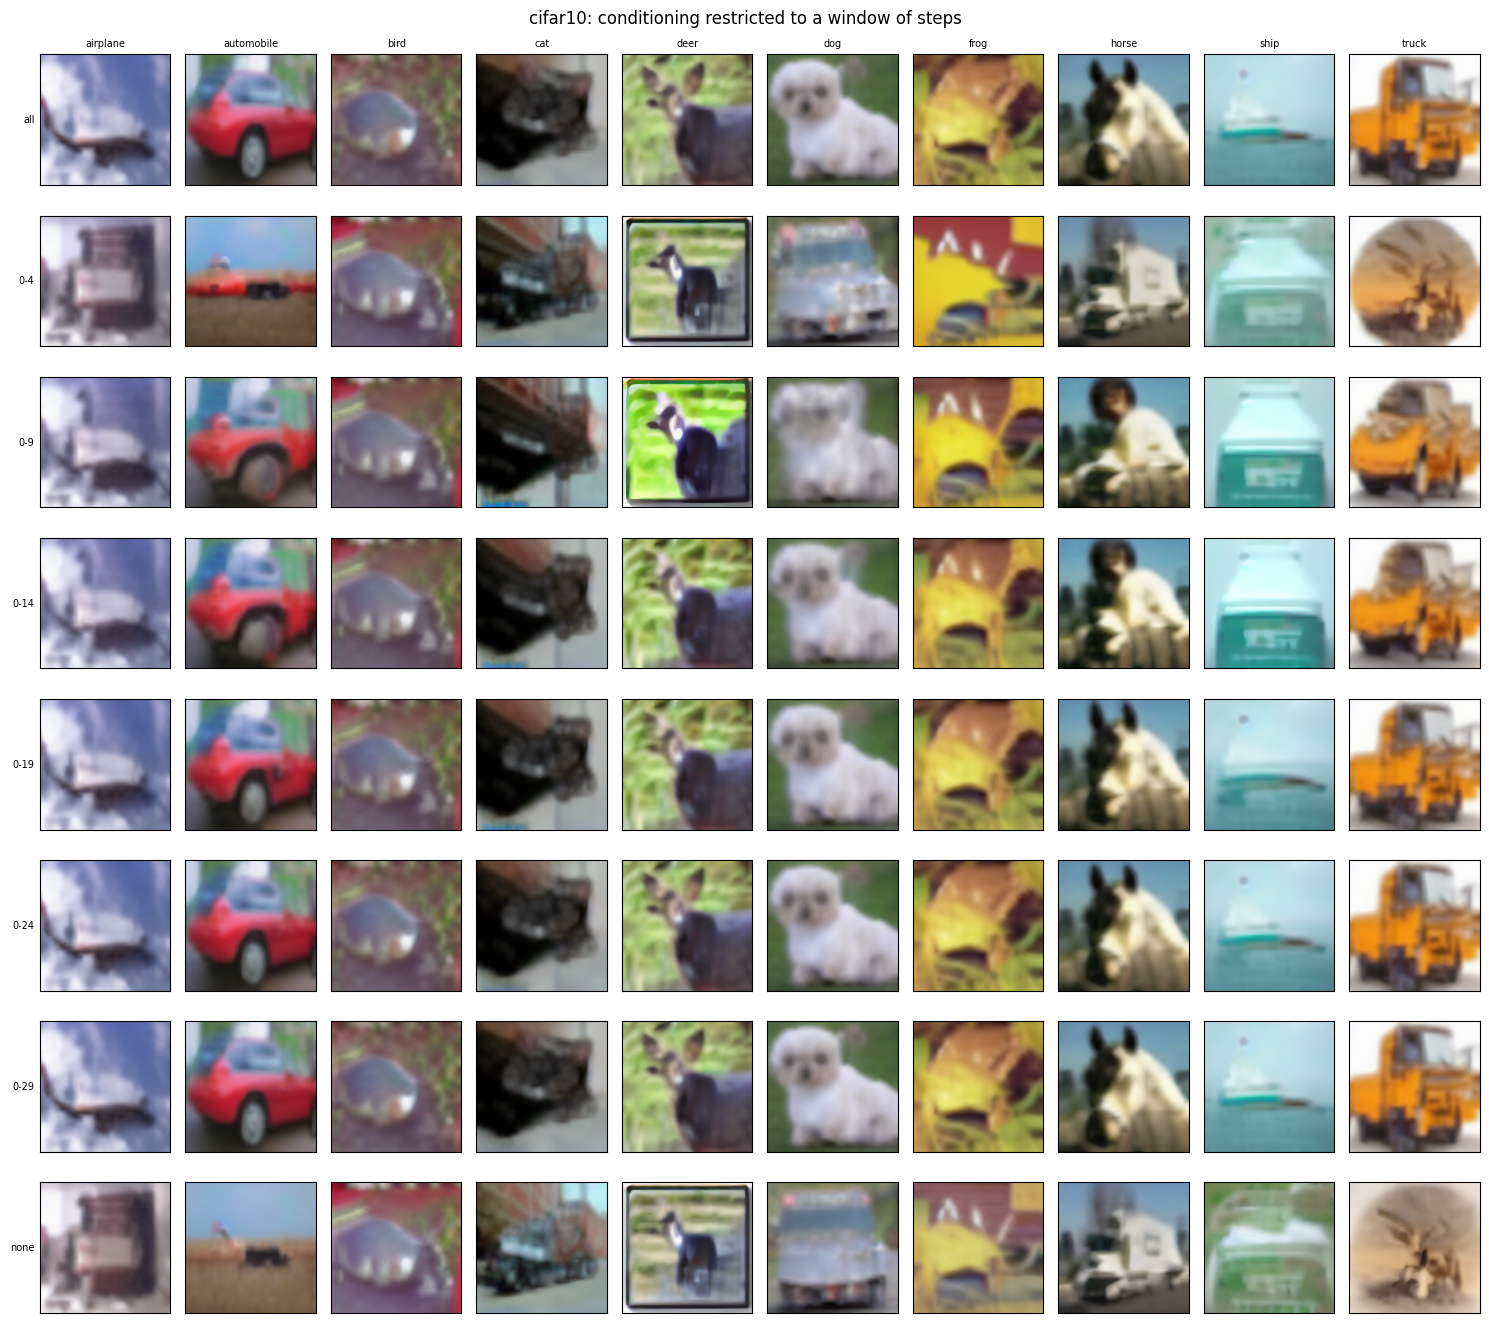

In [5]:
windows = np.load(f"XAI_Results/Exp_{EXP}/{DATASET}/windows/steps31_window5.npz")
names = [str(n) for n in windows["names"]]

# The context was tiled, not repeated, so the first indices are one per class and
# every column below shows the same class from the same initial noise.
first = np.arange(len(labels))

_ = plotting.image_grid([windows["images"][i][:len(labels)] for i in range(len(names))],
                        names, labels,
                        title=f"{DATASET}: conditioning restricted to a window of steps")
plt.show()

## Conclusion

> Conditioning reshapes the image mostly in the **early** steps, but carries **class
> identity** mostly in the **middle** of denoising. The first steps decide *what image
> this will be* — composition, background, dominant colours; the middle ones decide
> *what it is an image of*; the last ones refine without adding class.

Verified on CIFAR-10 and BloodMNIST — natural photographs and cells under a
microscope — with a judge validated on two independent checks (84.3% and 95.7%
accuracy on the respective real test sets) and the chance level reproduced exactly
(10.0% on both).

Three measurements of the same process point at three different moments, and only
one of them answers the question:

| measurement | strongest at | what it actually tracks |
|---|---|---|
| `‖ε(c) − ε(∅)‖` | the **end** | instantaneous signal, not its consequences |
| pixel distance | the **start** | how much the picture changes, class or not |
| class accuracy | the **middle** | whether the image belongs to its class |

One caveat, visible in the grid above: the last four rows look nearly identical yet
span **twenty points** of accuracy. Judging these images by eye is not enough — which
is why the class is scored by a classifier and not by us.

## Replication on BloodMNIST

The claim above is about the mechanism, not about natural images. BloodMNIST differs
in every respect — cells on a uniform background, eight classes, differences far
subtler than car-versus-frog — and was generated with its own optimal
hyper-parameters (IS = 44, UGS = 1.5162, windows of 11 steps). If the shape of the
curves survives that, it is a property of how conditioning enters the diffusion
process rather than of the pictures being generated.

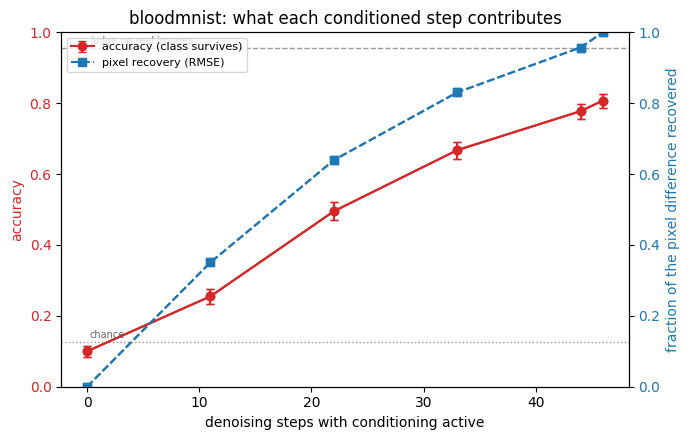

     steps     pixels      class
      0-10      35.1%      15.5
     11-21      28.9%      24.0
     22-32      19.1%      17.2
     33-43      12.7%      11.0
     44-45       4.3%       3.0


In [6]:
BLOOD = "bloodmnist"
blood_labels = common.get_labels(BLOOD)
blood = np.load(f"XAI_Results/Exp_{EXP}/{BLOOD}/windows/"
                f"accuracy_steps44_window11.npz")

_ = plotting.conditioning_curves(
    blood["counts"], blood["accuracy"], blood["error"], blood["recovered"],
    chance=1 / len(blood_labels), ceiling=float(blood["real_accuracy"]),
    title=f"{BLOOD}: what each conditioned step contributes")
plt.show()

print(f"{'steps':>10} {'pixels':>10} {'class':>10}")
for i in range(len(blood["counts"]) - 1):
    block = f"{blood['counts'][i]}-{blood['counts'][i + 1] - 1}"
    print(f"{block:>10} "
          f"{100 * (blood['recovered'][i + 1] - blood['recovered'][i]):>9.1f}% "
          f"{100 * (blood['accuracy'][i + 1] - blood['accuracy'][i]):>9.1f}")

## Sanity checks

Everything above rests on one assumption: that what we varied is the class
conditioning, and not something else in the pipeline. Three ablations test it,
generating with everything identical except the context handed to the UNet.

| context | vs requested label | vs supplied embedding |
|---|---|---|
| trained encoder | 64.4% | — |
| **embeddings permuted** (c → c+1) | **5.6%** | **65.0%** |
| untrained encoder | 9.0% | — |
| chance | 10.0% | |

The permuted run is the sharp one. Giving every class the *next* class's embedding
does not break generation — it **redirects** it, with undiminished effectiveness:
65.0% against the embedding actually supplied, against 64.4% for the untouched
model. And accuracy on the *requested* label falls **below chance**: with a c → c+1
shift that class is never produced on purpose, so it lands under the 10% a coin flip
would give. A pipeline artefact would survive randomisation; it would not survive
this.

The untrained encoder gives 9.0%, indistinguishable from chance: what we measure
depends on the learned weights, not on the architecture or the pipeline.

**On the numbers.** These were produced at IS = 20 and UGS = 1.0, not at the optimal
hyper-parameters used everywhere else — hence 64.4% rather than 88.4% for full
conditioning. The reason is technical: at UGS = 1.0 the guidance reduces to `ε(c)`,
so replacing the conditional context is enough to ablate the conditioning. At UGS ≠ 1
the unconditional context also reaches the output and would have to be replaced too.
The checks are about specificity, which the lower absolute accuracy does not affect.

Reproduce with `python -m scripts.xai_sanity --dataset cifar10 --exp xAI --enc_epoch 31 --dif_epoch 10`.